# 01 - Exploratory Data Analysis

Este notebook registra a primeira leitura do dataset **Home Credit Default Risk** para o projeto de previsão de risco de crédito. A variável alvo é `TARGET`: `1` indica clientes com dificuldade de pagamento registrada na base e `0` indica clientes sem dificuldade registrada.

Nesta etapa eu ainda não quero treinar modelos. O objetivo é entender o tamanho da base, a qualidade inicial dos dados, o desbalanceamento da variável alvo e o comportamento de algumas variáveis financeiras e temporais importantes.

## 1. Imports e configurações

Vou usar apenas bibliotecas comuns do projeto. Os gráficos são salvos em `reports/figures` para reaproveitar depois no README ou no relatório final.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.ticker import PercentFormatter

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.utils.config import DEFAULT_PROCESSED_DATA_PATH, FIGURES_DIR, TARGET_COLUMN  # noqa: E402, I001

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", "{:.2f}".format)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42

## 2. Carregamento dos dados processados

A EDA parte do arquivo processado criado por `src/data/make_dataset.py`. Esse arquivo já remove colunas com mais de 60% de valores ausentes e duplicatas, mas ainda não aplica imputação, encoding ou engenharia de atributos para modelagem.

In [2]:
data_path = DEFAULT_PROCESSED_DATA_PATH

if not data_path.exists():
    raise FileNotFoundError(
        f"Processed dataset not found at {data_path}. "
        "Run: python src/data/make_dataset.py"
    )

df = pd.read_csv(data_path)

print(f"Arquivo carregado: {data_path}")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")

Arquivo carregado: C:\Users\lucas\OneDrive\Documentos\TI\Projects\ML\credit-risk\credit-risk-ml\data\processed\credit_risk_processed.csv
Shape: 307,511 rows x 105 columns


## 3. Visão geral do dataset

Antes de olhar relações com o alvo, faço uma checagem básica: dimensões, tipos de dados, primeiras linhas e estatísticas descritivas. Isso ajuda a detectar rapidamente colunas categóricas, escalas muito diferentes e possíveis valores fora do padrão.

In [3]:
overview = pd.DataFrame(
    {
        "metric": ["rows", "columns", "duplicated_rows"],
        "value": [df.shape[0], df.shape[1], df.duplicated().sum()],
    }
)
display(overview)

,metric,value
0,rows,307511
1,columns,105
2,duplicated_rows,0


In [4]:
dtype_summary = df.dtypes.value_counts().rename_axis("dtype").reset_index(name="count")
display(dtype_summary)

display(df.dtypes.to_frame("dtype").head(30))

,dtype,count
0,float64,49
1,int64,41
2,object,15


,dtype
SK_ID_CURR,int64
TARGET,int64
NAME_CONTRACT_TYPE,object
CODE_GENDER,object
FLAG_OWN_CAR,object
FLAG_OWN_REALTY,object
CNT_CHILDREN,int64
AMT_INCOME_TOTAL,float64
AMT_CREDIT,float64
AMT_ANNUITY,float64


In [5]:
display(df.head())

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,LANDAREA_AVG,LIVINGAREA_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,LANDAREA_MODE,LIVINGAREA_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,LANDAREA_MEDI,LIVINGAREA_MEDI,NONLIVINGAREA_MEDI,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.00,406597.50,24700.50,351000.00,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.02,-9461,-637,-3648.00,-2120,1,1,0,1,1,0,Laborers,1.00,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.08,0.26,0.14,0.02,0.04,0.97,0.00,0.07,0.08,0.04,0.02,0.00,0.03,0.04,0.97,0.00,0.07,0.08,0.04,0.02,0.00,0.03,0.04,0.97,0.00,0.07,0.08,0.04,0.02,0.00,block of flats,0.01,"Stone, brick",No,2.00,2.00,2.00,2.00,-1134.00,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,1.00
1,100003,0,Cash loans,F,N,N,0,270000.00,1293502.50,35698.50,1129500.00,Family,State servant,Higher education,Married,House / apartment,0.00,-16765,-1188,-1186.00,-291,1,1,0,1,1,0,Core staff,2.00,1,1,MONDAY,11,0,0,0,0,0,0,School,0.31,0.62,NaN,0.10,0.05,0.99,0.08,0.03,0.29,0.01,0.05,0.01,0.09,0.05,0.99,0.08,0.03,0.29,0.01,0.06,0.00,0.10,0.05,0.99,0.08,0.03,0.29,0.01,0.06,0.01,block of flats,0.07,Block,No,1.00,0.00,1.00,0.00,-828.00,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00
2,100004,0,Revolving loans,M,Y,Y,0,67500.00,135000.00,6750.00,135000.00,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.01,-19046,-225,-4260.00,-2531,1,1,1,1,1,0,Laborers,1.00,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.56,0.73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,0.00,0.00,-815.00,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00
3,100006,0,Cash loans,F,N,Y,0,135000.00,312682.50,29686.50,297000.00,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.01,-19005,-3039,-9833.00,-2437,1,1,0,1,0,0,Laborers,2.00,2,2,WEDNESDAY,17,0,0,0,0,0,0,Business Entity Type 3,NaN,0.65,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.00,0.00,2.00,0.00,-617.00,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.00,513000.00,21865.50,513

In [6]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.00,NaN,NaN,NaN,278180.52,102790.18,100002.00,189145.50,278202.00,367142.50,456255.00
TARGET,307511.00,NaN,NaN,NaN,0.08,0.27,0.00,0.00,0.00,0.00,1.00
NAME_CONTRACT_TYPE,307511,2,Cash loans,278232,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CODE_GENDER,307511,3,F,202448,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLAG_OWN_CAR,307511,2,N,202924,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,265992.00,NaN,NaN,NaN,0.01,0.11,0.00,0.00,0.00,0.00,9.00
AMT_REQ_CREDIT_BUREAU_WEEK,265992.00,NaN,NaN,NaN,0.03,0.20,0.00,0.00,0.00,0.00,8.00
AMT_REQ_CREDIT_BUREAU_MON,265992.00,NaN,NaN,NaN,0.27,0.92,0.00,0.00,0.00,0.00,27.00
AMT_REQ_CREDIT_BUREAU_QRT,265992.00,NaN,NaN,NaN,0.27,0.79,0.00,0.00,0.00,0.00,261.00


## 4. Análise da variável TARGET

A distribuição do `TARGET` é uma das primeiras coisas que preciso entender. Em risco de crédito, é comum a classe de inadimplência ser minoritária, e isso influencia validação, métricas e escolha de threshold.

In [7]:
if TARGET_COLUMN not in df.columns:
    raise ValueError(f"Target column {TARGET_COLUMN!r} was not found in the dataset.")

target_counts = df[TARGET_COLUMN].value_counts().sort_index()
target_percent = (target_counts / target_counts.sum() * 100).round(2)
target_distribution = pd.DataFrame(
    {
        "count": target_counts,
        "percent": target_percent,
    }
)

display(target_distribution)

,count,percent
TARGET,,
0,282686,91.93
1,24825,8.07


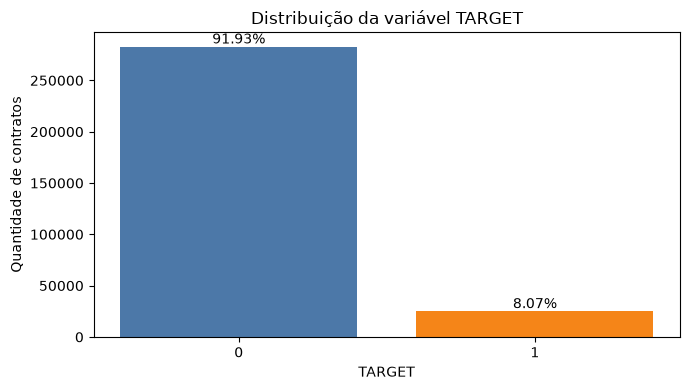

Figura salva em: C:\Users\lucas\OneDrive\Documentos\TI\Projects\ML\credit-risk\credit-risk-ml\reports\figures\target_distribution.png


In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(target_counts.index.astype(str), target_counts.values, color=["#4C78A8", "#F58518"])

ax.set_title("Distribuição da variável TARGET")
ax.set_xlabel("TARGET")
ax.set_ylabel("Quantidade de contratos")

for bar, percent in zip(bars, target_percent, strict=True):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{percent:.2f}%",
        ha="center",
        va="bottom",
    )

fig.tight_layout()
target_fig_path = FIGURES_DIR / "target_distribution.png"
fig.savefig(target_fig_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figura salva em: {target_fig_path}")

A classe `1` é a classe de maior interesse para o problema, mas ela não deve ser tratada como se tivesse o mesmo peso operacional da classe `0`. Na modelagem, vou acompanhar métricas como PR-AUC, recall da classe `1`, precision da classe `1` e matriz de confusão, além de ROC-AUC.

## 5. Valores ausentes

O script de preparação já removeu colunas com mais de 60% de nulos. Mesmo assim, ainda preciso mapear os nulos restantes, porque a etapa de features deve decidir como imputar variáveis numéricas e categóricas.

In [9]:
missing_summary = (
    df.isna()
    .agg(["sum", "mean"])
    .T.rename(columns={"sum": "missing_count", "mean": "missing_percent"})
    .sort_values("missing_percent", ascending=False)
)
missing_summary["missing_percent"] = missing_summary["missing_percent"] * 100

display(missing_summary.head(20))

,missing_count,missing_percent
LANDAREA_AVG,182590.00,59.38
LANDAREA_MODE,182590.00,59.38
LANDAREA_MEDI,182590.00,59.38
BASEMENTAREA_AVG,179943.00,58.52
BASEMENTAREA_MODE,179943.00,58.52
BASEMENTAREA_MEDI,179943.00,58.52
EXT_SOURCE_1,173378.00,56.38
NONLIVINGAREA_AVG,169682.00,55.18
NONLIVINGAREA_MODE,169682.00,55.18
NONLIVINGAREA_MEDI,169682.00,55.18


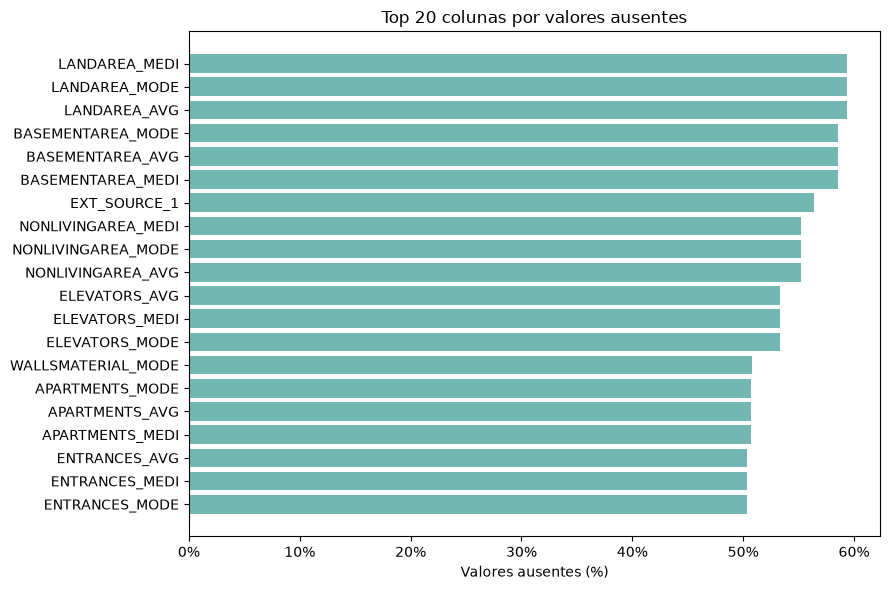

Figura salva em: C:\Users\lucas\OneDrive\Documentos\TI\Projects\ML\credit-risk\credit-risk-ml\reports\figures\missing_values_top20.png


In [10]:
top_missing = missing_summary.query("missing_count > 0").head(20).sort_values("missing_percent")

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_missing.index, top_missing["missing_percent"], color="#72B7B2")
ax.set_title("Top 20 colunas por valores ausentes")
ax.set_xlabel("Valores ausentes (%)")
ax.xaxis.set_major_formatter(PercentFormatter())
fig.tight_layout()

missing_fig_path = FIGURES_DIR / "missing_values_top20.png"
fig.savefig(missing_fig_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figura salva em: {missing_fig_path}")

## 6. Variáveis numéricas importantes

Nesta primeira rodada vou olhar variáveis que fazem sentido para crédito: renda, valor do crédito, anuidade e variáveis temporais ligadas a idade e emprego. `DAYS_BIRTH` e `DAYS_EMPLOYED` vêm em dias negativos no dataset original; para facilitar a leitura, também crio versões aproximadas em anos.

In [11]:
important_numeric_features = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
]

missing_important_features = [
    column for column in important_numeric_features if column not in df.columns
]
if missing_important_features:
    raise ValueError(f"Missing expected columns: {missing_important_features}")

eda_df = df.copy()
eda_df["AGE_YEARS"] = (-eda_df["DAYS_BIRTH"] / 365.25).round(1)
eda_df["DAYS_EMPLOYED_CLEAN"] = eda_df["DAYS_EMPLOYED"].replace(365243, np.nan)
eda_df["YEARS_EMPLOYED"] = (-eda_df["DAYS_EMPLOYED_CLEAN"] / 365.25).round(1)

numeric_overview_features = important_numeric_features + ["AGE_YEARS", "YEARS_EMPLOYED"]
numeric_summary = eda_df[numeric_overview_features].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).T

display(numeric_summary)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
AMT_INCOME_TOTAL,307511.00,168797.92,237123.15,25650.00,45000.00,67500.00,112500.00,147150.00,202500.00,337500.00,472500.00,117000000.00
AMT_CREDIT,307511.00,599026.00,402490.78,45000.00,76410.00,135000.00,270000.00,513531.00,808650.00,1350000.00,1854000.00,4050000.00
AMT_ANNUITY,307499.00,27108.57,14493.74,1615.50,6182.91,9000.00,16524.00,24903.00,34596.00,53325.00,70006.50,258025.50
DAYS_BIRTH,307511.00,-16037.00,4363.99,-25229.00,-24419.00,-23204.00,-19682.00,-15750.00,-12413.00,-9407.00,-8263.00,-7489.00
DAYS_EMPLOYED,307511.00,63815.05,141275.77,-17912.00,-10894.90,-6742.50,-2760.00,-1213.00,-289.00,365243.00,365243.00,365243.00
AGE_YEARS,307511.00,43.91,11.95,20.50,22.60,25.80,34.00,43.10,53.90,63.50,66.90,69.10
YEARS_EMPLOYED,252137.00,6.53,6.40,0.00,0.30,0.60,2.10,4.50,8.70,20.00,31.00,49.00


O valor especial `365243` em `DAYS_EMPLOYED` aparece no dataset Home Credit e não representa uma quantidade comum de dias trabalhados. Para a visualização em anos empregados, trato esse valor como ausente. Na modelagem, essa decisão precisa ser documentada e testada com cuidado.

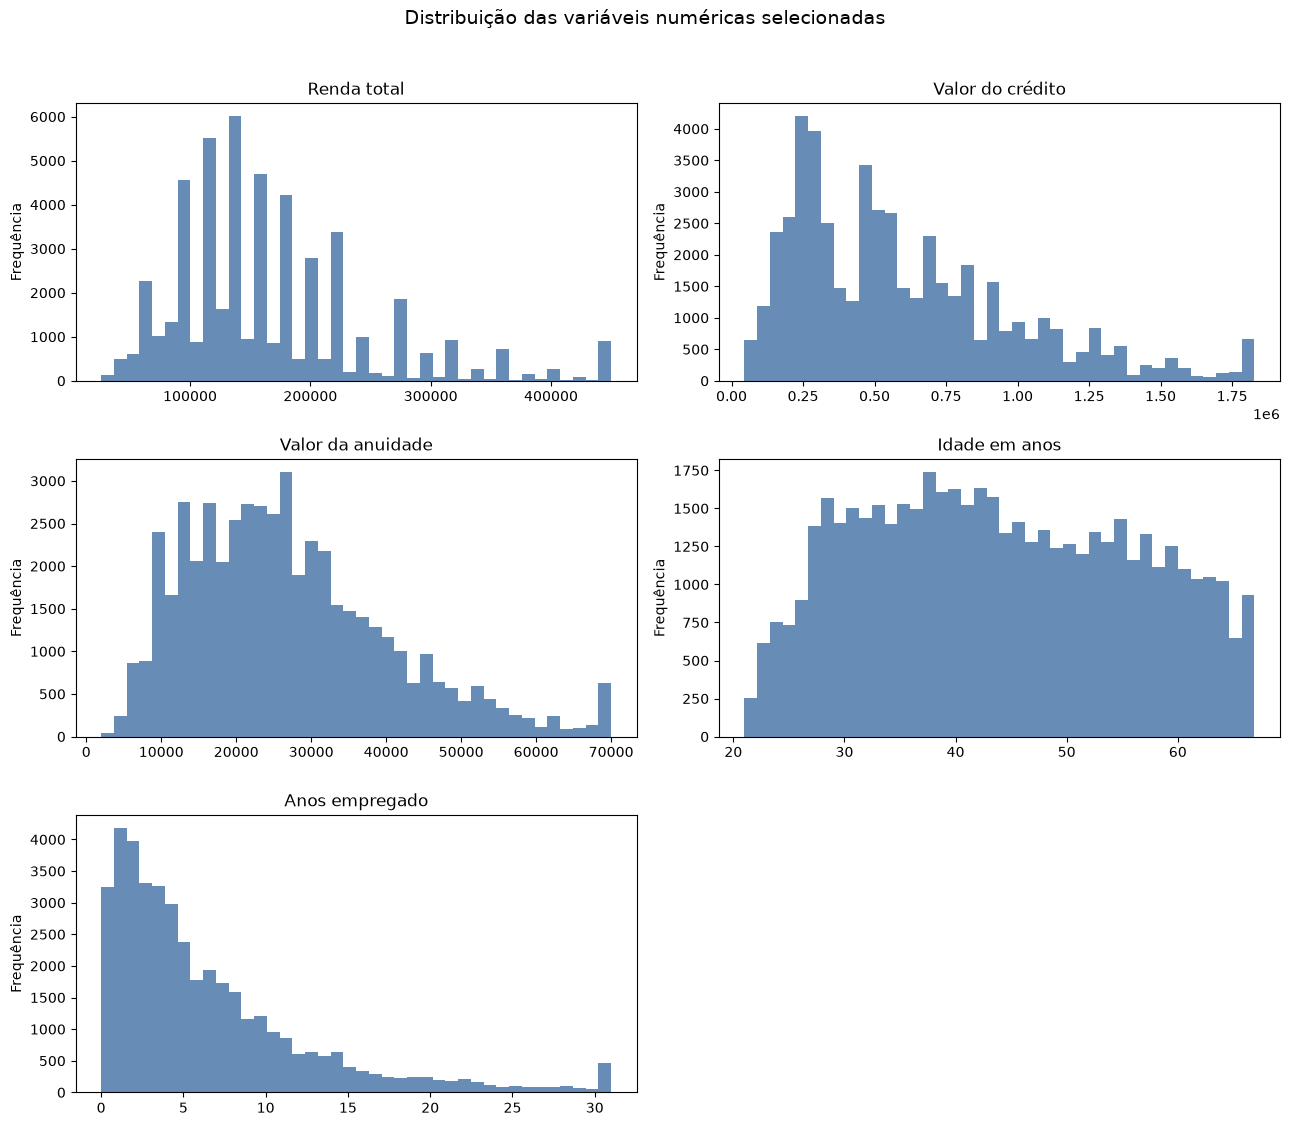

Figura salva em: C:\Users\lucas\OneDrive\Documentos\TI\Projects\ML\credit-risk\credit-risk-ml\reports\figures\numeric_distributions.png


In [12]:
plot_sample = eda_df.sample(min(50_000, len(eda_df)), random_state=RANDOM_STATE)

plot_features = {
    "AMT_INCOME_TOTAL": "Renda total",
    "AMT_CREDIT": "Valor do crédito",
    "AMT_ANNUITY": "Valor da anuidade",
    "AGE_YEARS": "Idade em anos",
    "YEARS_EMPLOYED": "Anos empregado",
}


def clip_for_plot(series: pd.Series, upper_quantile: float = 0.99) -> pd.Series:
    upper_limit = series.quantile(upper_quantile)
    return series.clip(upper=upper_limit)


fig, axes = plt.subplots(3, 2, figsize=(13, 11))
axes = axes.flatten()

for ax, (column, title) in zip(axes, plot_features.items(), strict=False):
    values = clip_for_plot(plot_sample[column].dropna())
    ax.hist(values, bins=40, color="#4C78A8", alpha=0.85)
    ax.set_title(title)
    ax.set_ylabel("Frequência")

for ax in axes[len(plot_features):]:
    ax.axis("off")

fig.suptitle("Distribuição das variáveis numéricas selecionadas", y=1.02, fontsize=14)
fig.tight_layout()

numeric_dist_fig_path = FIGURES_DIR / "numeric_distributions.png"
fig.savefig(numeric_dist_fig_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figura salva em: {numeric_dist_fig_path}")

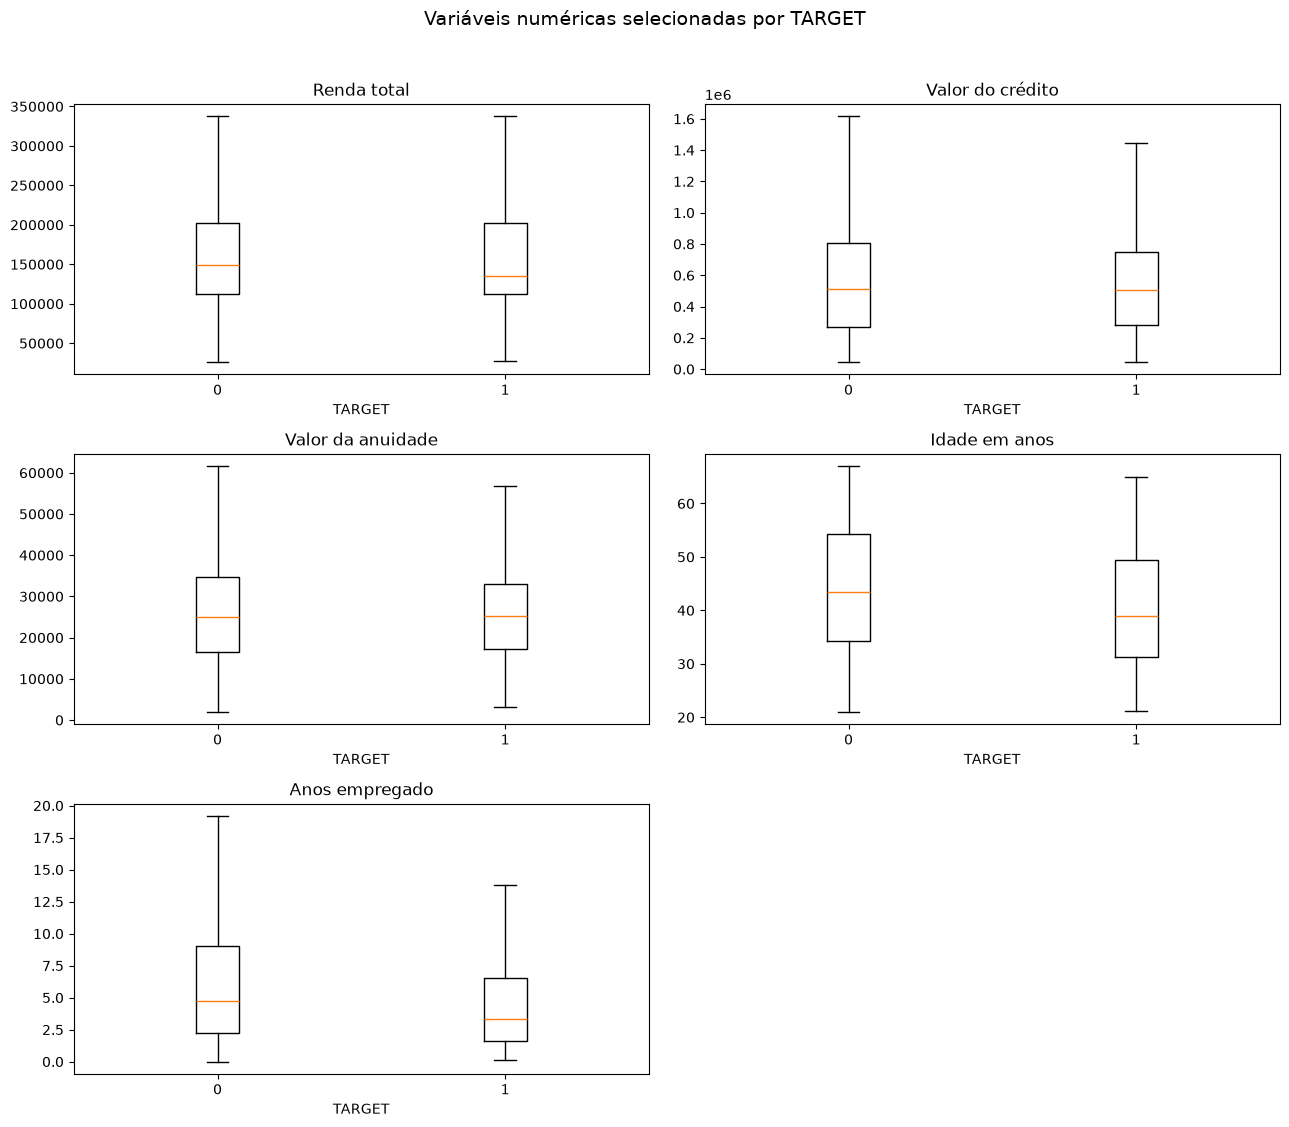

Figura salva em: C:\Users\lucas\OneDrive\Documentos\TI\Projects\ML\credit-risk\credit-risk-ml\reports\figures\numeric_boxplots_by_target.png


In [13]:
fig, axes = plt.subplots(3, 2, figsize=(13, 11))
axes = axes.flatten()

for ax, (column, title) in zip(axes, plot_features.items(), strict=False):
    grouped_values = []
    labels = []
    for target_value in sorted(plot_sample[TARGET_COLUMN].dropna().unique()):
        series = plot_sample.loc[plot_sample[TARGET_COLUMN] == target_value, column].dropna()
        grouped_values.append(clip_for_plot(series))
        labels.append(str(target_value))

    ax.boxplot(grouped_values, tick_labels=labels, showfliers=False)
    ax.set_title(title)
    ax.set_xlabel("TARGET")

for ax in axes[len(plot_features):]:
    ax.axis("off")

fig.suptitle("Variáveis numéricas selecionadas por TARGET", y=1.02, fontsize=14)
fig.tight_layout()

numeric_target_fig_path = FIGURES_DIR / "numeric_boxplots_by_target.png"
fig.savefig(numeric_target_fig_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figura salva em: {numeric_target_fig_path}")

## 7. Comparação rápida por TARGET

Aqui comparo medianas por classe. A mediana é uma escolha mais estável para esta leitura inicial porque algumas variáveis monetárias têm caudas longas.

In [14]:
comparison_features = list(plot_features.keys())
median_by_target = eda_df.groupby(TARGET_COLUMN)[comparison_features].median().T
median_by_target.columns = [f"TARGET_{column}" for column in median_by_target.columns]

if {"TARGET_0", "TARGET_1"}.issubset(median_by_target.columns):
    median_by_target["relative_diff_target_1_vs_0_%"] = (
        (median_by_target["TARGET_1"] - median_by_target["TARGET_0"])
        / median_by_target["TARGET_0"].replace(0, np.nan)
        * 100
    ).round(2)

display(median_by_target)

,TARGET_0,TARGET_1,relative_diff_target_1_vs_0_%
AMT_INCOME_TOTAL,148500.00,135000.00,-9.09
AMT_CREDIT,517788.00,497520.00,-3.91
AMT_ANNUITY,24876.00,25263.00,1.56
AGE_YEARS,43.50,39.10,-10.11
YEARS_EMPLOYED,4.60,3.40,-26.09


## 8. Main takeaways

As observações abaixo são geradas a partir dos dados carregados neste notebook. Eu evito tratar essas diferenças como causalidade; por enquanto elas servem para orientar as próximas etapas de feature engineering e modelagem.

In [15]:
positive_share = target_percent.get(1, np.nan)
top_missing_column = missing_summary.index[0]
top_missing_percent = missing_summary.iloc[0]["missing_percent"]
duplicates = int(df.duplicated().sum())

takeaways = [
    f"O dataset processado tem **{df.shape[0]:,} linhas** e **{df.shape[1]:,} colunas**.",
    f"A classe positiva (`TARGET = 1`) representa **{positive_share:.2f}%** dos contratos, então este é um problema de classificação desbalanceado.",
    f"Depois da etapa de preparação, o arquivo ficou com **{duplicates:,}** linhas duplicadas.",
    f"A coluna com maior percentual de nulos restantes é **`{top_missing_column}`**, com **{top_missing_percent:.2f}%**.",
    "As variáveis monetárias selecionadas têm caudas longas, então medianas e pré-processamento robusto devem ser úteis nas próximas etapas.",
    "`DAYS_EMPLOYED` precisa de cuidado porque o valor especial `365243` do Home Credit não deve ser interpretado como duração comum de emprego.",
]

display(Markdown("\n".join(f"- {item}" for item in takeaways)))

- O dataset processado tem **307,511 linhas** e **105 colunas**.
- A classe positiva (`TARGET = 1`) representa **8.07%** dos contratos, então este é um problema de classificação desbalanceado.
- Depois da etapa de preparação, o arquivo ficou com **0** linhas duplicadas.
- A coluna com maior percentual de nulos restantes é **`LANDAREA_AVG`**, com **59.38%**.
- As variáveis monetárias selecionadas têm caudas longas, então medianas e pré-processamento robusto devem ser úteis nas próximas etapas.
- `DAYS_EMPLOYED` precisa de cuidado porque o valor especial `365243` do Home Credit não deve ser interpretado como duração comum de emprego.